In [1]:
import astropy.coordinates as coord
import matplotlib.pylab as plt
import matplotlib.cm as cm
import matplotlib as mlp
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon
from matplotlib.ticker import FormatStrFormatter
from astropy.coordinates import SkyCoord
import astropy.units as units
import os
from matplotlib.cm import ScalarMappable

In [2]:
# all corners
fname = 'ztf_field_corners.csv'
data = pd.read_csv(fname)

In [3]:
files = os.listdir('../dr23-features/collected_by_field')
dr23_fields = [np.int64(filename[:-4].split('_')[-1]) for filename in files if filename.endswith('.dat')]

density = []
for filename in files:
    if filename.endswith('.dat') and 'oid' in filename.split('_'):
        density.append([np.int64(filename[:-4].split('_')[-1]),
                        len(np.memmap(f'../dr23-features/collected_by_field/{filename}', mode='c', dtype=np.uint64))])

density = pd.DataFrame(data=density, columns=['field', 'n']).sort_values('field').reset_index(drop=True)

In [4]:
# Data filtering
coord_corners = data[data['field'].isin(dr23_fields)]
coord_corners = coord_corners.reset_index(drop=True)
coord_corners['n'] = density['n']

In [5]:
def split_polygon_at_180(ra, dec):
    # Проверяем пересечение RA=180°
    # if max(ra) > 180 and min(ra) < 180 and max(ra) < 250:
    #     return True

    if abs(ra.max() - ra.min()) > 200/180*np.pi:
        return True

    return False


# 3. Функция для преобразования координат
def convert_coords(ra_list, dec_list):
    coords = SkyCoord(ra=ra_list * units.deg, dec=dec_list * units.deg, frame='icrs')
    ra_rad = -coords.ra.wrap_at(180 * units.deg).radian
    dec_rad = coords.dec.radian
    return np.column_stack([ra_rad, dec_rad])

In [13]:
# Прямое восхождение (RA) в градусах
ra_proj = [
    300.0,        # Stripe 82 (среднее значение)
    150.1025,     # COSMOS
    #189.2054,     # GOODS-North (HDF-N)
    #53.1250,      # GOODS-South (CDF-S)
    189.2372,     # Hubble Deep Field (HDF-N)
    #338.2942,     # Hubble Deep Field South (HDF-S)
    #53.0833,      # Extended Chandra Deep Field South (ECDFS)
    161.25,       # Lockman Hole
    242.5042,     # ELAIS-N1
   # 8.6833,       # ELAIS-S1
    218.0220      # Boötes Field (NDWFS)
]

# Склонение (Dec) в градусах
dec_proj = [
    0.0,          # Stripe 82 (среднее значение)
    2.1758,       # COSMOS
    #62.2161,      # GOODS-North (HDF-N)
    #-27.8056,     # GOODS-South (CDF-S)
    62.2131,      # Hubble Deep Field (HDF-N)
    #-60.5895,     # Hubble Deep Field South (HDF-S)
    #-27.8094,     # Extended Chandra Deep Field South (ECDFS)
    58.0,         # Lockman Hole
    54.5100,      # ELAIS-N1
    #-43.4700,     # ELAIS-S1
    34.2799       # Boötes Field (NDWFS)
]

proj_name = [
    'Stripe 82',
    'COSMOS',
    #'GOODS-North (HDF-N)',
    #'GOODS-South (CDF-S)',
    'Hubble Deep Field (HDF-N)',
    #'Hubble Deep Field South (HDF-S)',
    #'Extended Chandra Deep Field South (ECDFS)',
    'Lockman Hole',
    'ELAIS-N1',
    #'ELAIS-S1',
    'Boötes Field (NDWFS)'
]

proj_plot_coord = convert_coords(ra_proj, dec_proj)

/tmp/ipykernel_1464/3946212138.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian,
/tmp/ipykernel_1464/3946212138.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  im_m = plt.scatter(-m31.icrs.ra.wrap_at(180 * units.deg).radian,
/tmp/ipykernel_1464/3946212138.py:72: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(proj_plot_coord[i][0],


Edge fields: 23


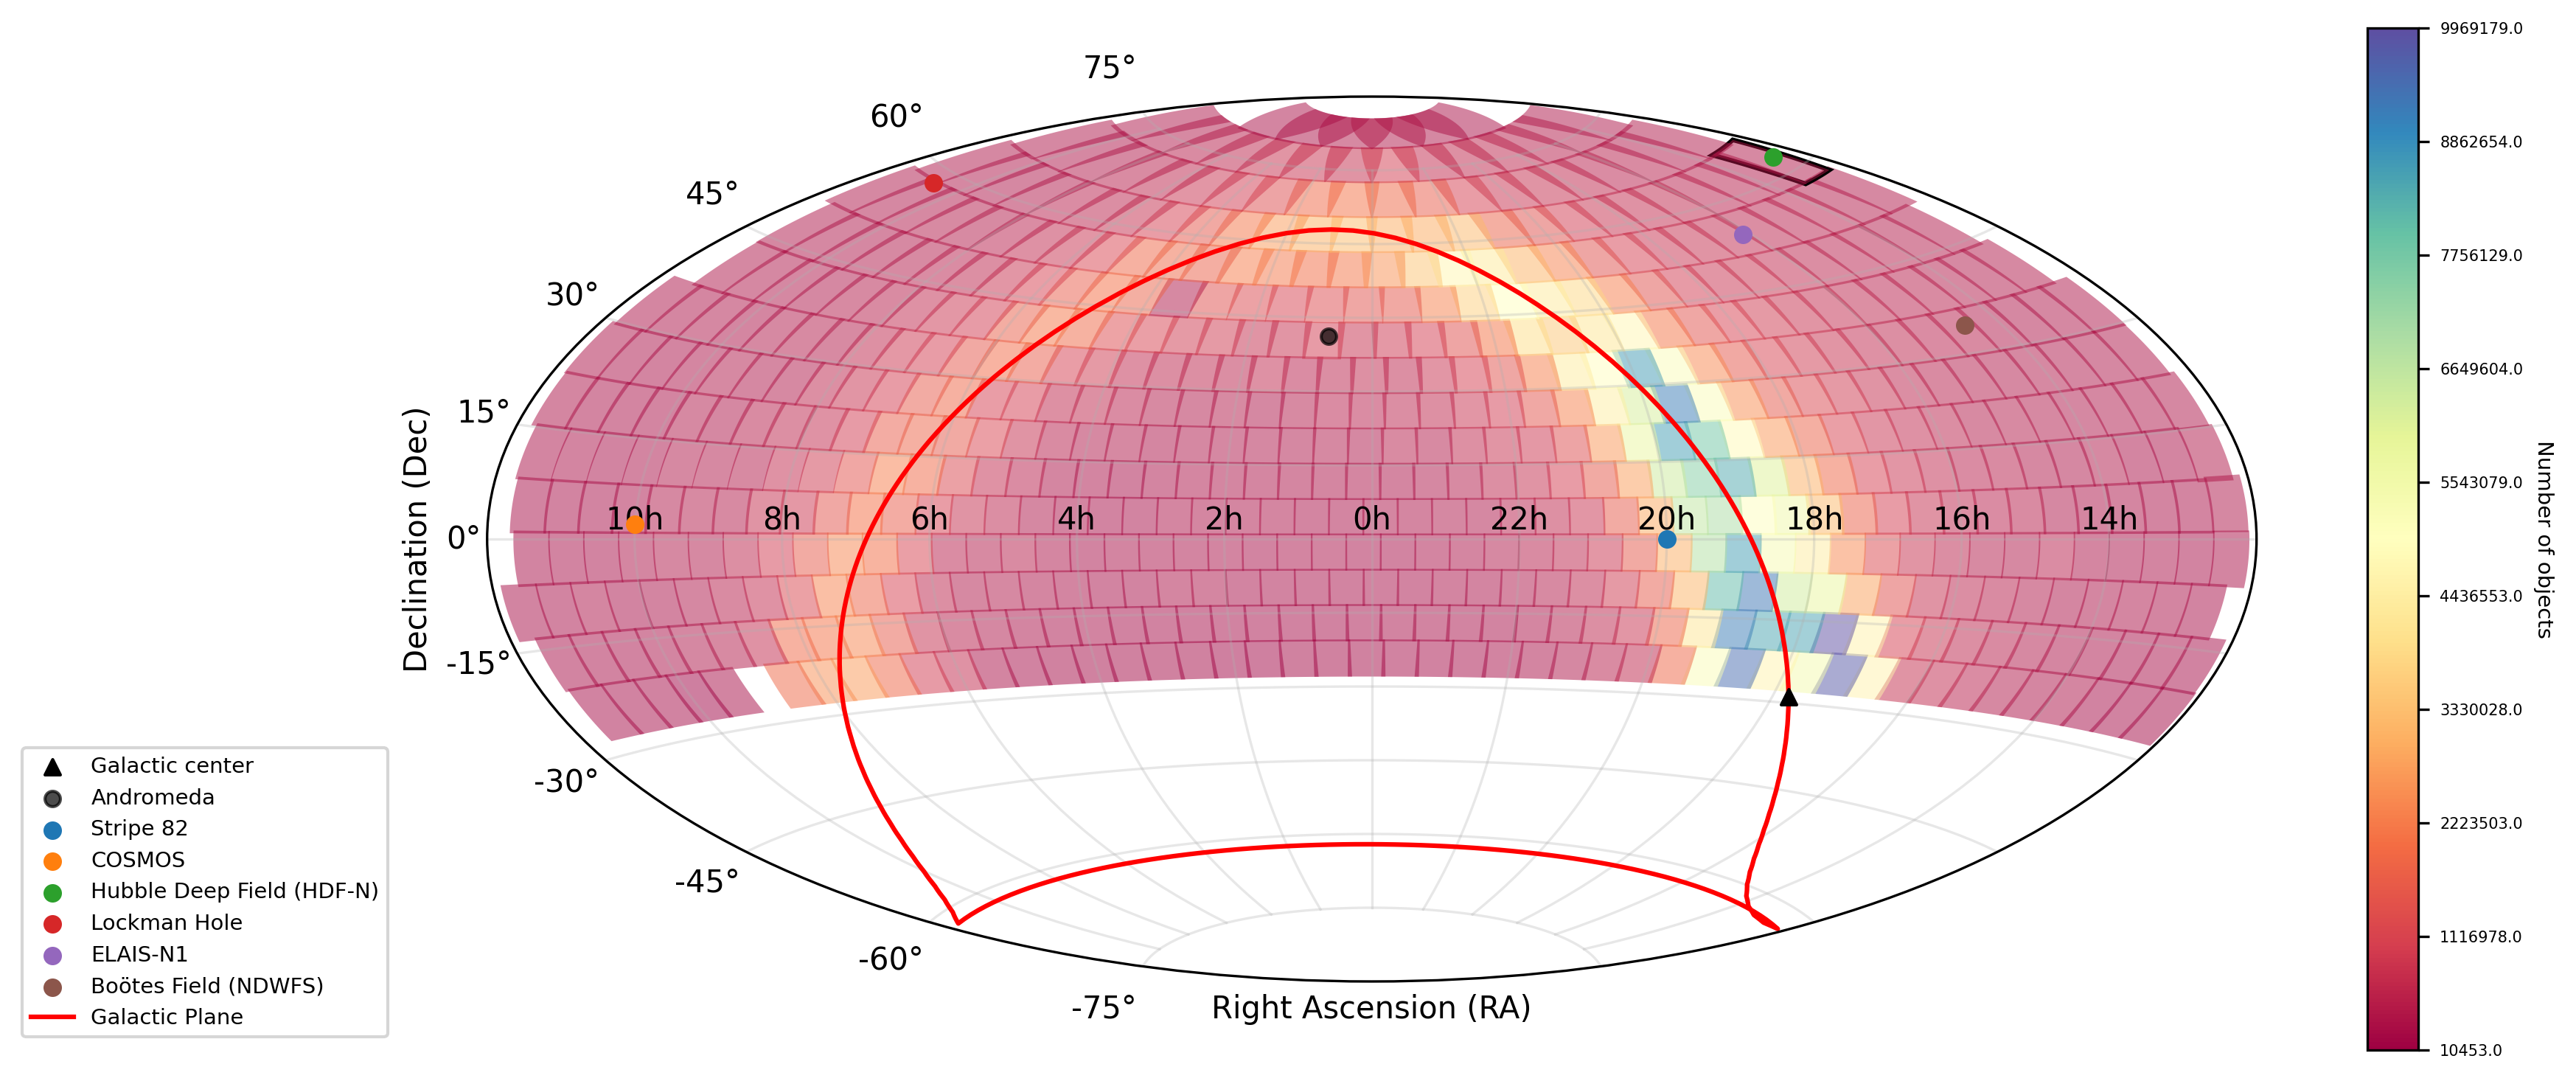

In [48]:
# Настройка графика
plt.figure(figsize=(10, 6), dpi=300)
ax = plt.subplot(111, projection='aitoff')
ax.grid(zorder=0.5, alpha=0.3)

# Пример: галактическая плоскость
c_galactic = SkyCoord(l=np.linspace(0, 360, 100)*units.deg, b=np.zeros(100)*units.deg, frame='galactic')
c_equatorial = c_galactic.icrs

# Инверсия RA (справа налево)
ra_plot = -c_equatorial.ra.wrap_at(180 * units.deg).radian
dec_plot = c_equatorial.dec.radian

gc = SkyCoord(l=0*units.degree, b=0*units.degree, frame='galactic')
im_c = plt.scatter(-gc.icrs.ra.wrap_at(180 * units.deg).radian, 
                   gc.icrs.dec.radian, cmap='PuBu', s=25 ,marker='^',
                   edgecolor=None, zorder=5, color='black', label='Galactic center')


# add M31
m31 = SkyCoord(l=(121.174329)*units.degree, 
               b=(-21.573309)*units.degree, frame='galactic')
im_m = plt.scatter(-m31.icrs.ra.wrap_at(180 * units.deg).radian, 
                   m31.icrs.dec.radian, cmap='PuBu', s=25,
                   edgecolor=None, zorder=5, color = 'black', label='Andromeda', 
                   alpha =0.7)


# 3. Найдем диапазон плотностей для цветовой шкалы
densities = coord_corners['n']
norm = Normalize(vmin=min(densities), vmax=max(densities))
cmap = plt.cm.Spectral #plt.get_cmap('viridis')  # Можно выбрать другую цветовую карту
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

edge_field_n = 0
for ind, row in coord_corners.iterrows():
    # Получаем координаты вершин
    ra_coords = [row['ra1'], row['ra2'], row['ra3'], row['ra4']]
    dec_coords = [row['dec1'], row['dec2'], row['dec3'], row['dec4']]

    # if split_polygon_at_180(ra_coords, dec_coords):
    #     edge_field_n += 1
    #     continue
    
    # Преобразуем координаты
    polygon_vertices = convert_coords(ra_coords, dec_coords)


    if row['field'] == 820:
        p1 = Polygon(polygon_vertices, edgecolor='black', fill=None, alpha=1, zorder=1, linewidth=1.5)
        ax.add_patch(p1)
    
    if split_polygon_at_180(polygon_vertices[:, 0], polygon_vertices[:, 1]):
        edge_field_n += 1
        continue

    
    # Создаем полигон
    poly = Polygon(
        polygon_vertices,
        #closed=True,
        #edgecolor='black',
        facecolor=cmap(norm(row['n'])),
        #linewidth=1,
        alpha=0.5
    )
    ax.add_patch(poly)
    

for i, name in enumerate(proj_name):
    plt.scatter(proj_plot_coord[i][0], 
                proj_plot_coord[i][1],
                cmap='PuBu', s=25,
                edgecolor=None, zorder=5, label=name, 
                
               )

# Построение
ax.plot(ra_plot, dec_plot, 'r-', label='Galactic Plane')
ax.legend()

# Подписи осей
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'][::-1])
ax.set_xlabel('Right Ascension (RA)')
ax.set_ylabel('Declination (Dec)')


ticks = np.linspace(min(densities), max(densities), 10).round()
cbar = plt.colorbar(sm, ax=ax, ticks=ticks, format=FormatStrFormatter("%.1f"))
cbar.set_label("Number of objects", fontsize=7, rotation=270, labelpad=10)
cbar.ax.tick_params(labelsize=5)
cbar.ax.yaxis.get_offset_text().set_fontsize(5)

plt.legend(loc=4, fontsize=2.5)
plt.legend(bbox_to_anchor=(-0.05, -0.075), loc='lower right', fontsize=7)
plt.subplots_adjust(left=0.0, right=1)
#plt.title('Aitoff Projection')

print(f'Edge fields: {edge_field_n}')

In [44]:
for ind, row in coord_corners.iterrows():
    ra_coords = [row['ra1'], row['ra2'], row['ra3'], row['ra4']]
    dec_coords = [row['dec1'], row['dec2'], row['dec3'], row['dec4']]
    
    polygon_vertices = convert_coords(ra_coords, dec_coords)
    
    if (polygon_vertices[:, 1] < 70/180*np.pi).all() and (polygon_vertices[:, 1] > 55/180*np.pi).all() and (polygon_vertices[:, 0] > 360/24*10/180*np.pi).all() and (polygon_vertices[:, 0] < 360/24*12/180*np.pi).all():
        print(row['field'])
        break

820.0


In [27]:
fields = [477, 820]

2.6179938779914944